<a href="https://colab.research.google.com/github/ValTal5/ecg-arrhythmia-classification/blob/main/Valentino/ecg_arrhythmia_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Multi-class Classification on MIT-BIH Arrhythmia Database

**Course:** Artificial Intelligence in Medicine

**Authors:** Nicoletta Toma, Laura Tufo, Valentino Vacirca

---

## Narrative & Perspective

**Central question:** Can we build a deep learning system capable of accurately classifying heartbeat morphologies into specific clinical categories?

This is a **supervised multi-class classification** task. We aim to leverage professional cardiologist annotations to train models that recognize the specific 'signatures' of different arrhythmias.

Key challenges addressed in this project:
1. **Extreme Class Imbalance**: Some arrhythmias are thousands of times rarer than normal beats.
2. **Temporal Feature Extraction**: Capturing the intricate relationships between the P-wave, QRS complex, and T-wave.
3. **Modern Architectures**: Comparing traditional RNNs with state-of-the-art **Liquid Neural Networks (CfC)**.

---

## Model Strategy

We will explore architectures of increasing complexity to handle the sequential nature of ECG signals:

| Model | Type | Learning Paradigm |
|---|---|---|
| Random Forest | Baseline | Statistical features (Mean, Std, Skewness) |
| 1D-CNN | Deep Learning | Automated spatial feature extraction |
| Bi-LSTM | Deep Learning | Recurrent sequential dependencies |
| **Liquid NN (CfC)** | **SOTA** | **Closed-form Continuous-time neural networks** |

---

---
## 1. Setup and Data Loading

### 1.1 Dependencies

All standard scientific libraries (numpy, matplotlib, sklearn, torch) are already installed on Colab. We only need to install two additional packages:

- **`wfdb`**: official PhysioNet library for reading ECG records (`.dat` / `.hea` / `.atr` files).
- **`ncps`**: Neural Circuit Policies —> provides the **CfC (Liquid NN)** implementation.

### 1.1.1 Google Drive Mounting

In [20]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

# Path to the dataset
DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
!pip install wfdb ncps --quiet

### 1.2 Imports and Global Settings

In [22]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import wfdb

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Segmentation constants
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cpu


### Segmentation Logic

To transform the continuous ECG signal into a dataset suitable for classification, we apply a windowing process centered around the **R-peak** (provided by the clinical annotations):

1.  **Fixed-Width Windows**: For each annotated heartbeat, we extract a segment of signal surrounding the R-peak.
2.  **Window Parameters**: We use a `HALF_WINDOW` of 90 samples. At a sampling rate of 360 Hz, this captures 250ms before and 250ms after the peak, resulting in a total `BEAT_LEN` of 180 samples (approx. 500ms).
3.  **Signal Normalization**: Each extracted segment is typically Z-score normalized (zero mean, unit variance) to ensure that the model learns morphological patterns rather than absolute amplitude variations between different recordings.

This approach ensures that each input sample contains the full QRS complex and the immediate surrounding temporal context necessary for arrhythmia identification.

### 1.3 Download MIT-BIH from PhysioNet

The MIT-BIH Arrhythmia Database contains 48 two-channel ambulatory ECG recordings, each approximately 30 minutes long, sampled at **360 Hz**. Every beat is annotated with a symbol by trained cardiologists (e.g. `N` = normal sinus, `V` = premature ventricular contraction, `A` = atrial premature beat).

In [23]:
import zipfile

# Path
DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')
ZIP_PATH = '/content/mit-bih-arrhythmia-database-1.0.0.zip'

if not os.path.exists(DATA_DIR):
    if os.path.exists(ZIP_PATH):
        print(f"Extracting dataset from {ZIP_PATH}...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(DRIVE_PATH)

        extracted_folder = os.path.join(DRIVE_PATH, 'mit-bih-arrhythmia-database-1.0.0')
        if os.path.exists(extracted_folder):
            os.rename(extracted_folder, DATA_DIR)
        print("Extraction completed.")
    else:
        print('Downloading from PhysioNet...')
        wfdb.dl_database('mitdb', DATA_DIR)
        print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')




Dataset already present in /content/drive/MyDrive/ECG_Project/mitdb.


### 1.4 AAMI Mapping Detail

To make the results clinically relevant, we follow the **AAMI EC57** recommendation. This standard groups the original MIT-BIH symbols into 5 main categories:

| AAMI Class | Description | MIT-BIH Symbols |
|---|---|---|
| **N** (Normal) | Normal beat, Left/Right bundle branch block | `N`, `L`, `R`, `e`, `j` |
| **S** (SVEB) | Supraventricular ectopic beat | `A`, `a`, `J`, `S` |
| **V** (VEB) | Ventricular ectopic beat | `V`, `E` |
| **F** (Fusion) | Fusion of ventricular and normal beat | `F` |
| **P** (Paced) | Paced beat, fusion of paced and normal | `/`, `f` |

*Note: 'Unknown' (Q) and 'Other' symbols are typically excluded from the primary classification to maintain focus on diagnostic categories.*

In [24]:
def get_aami_category(symbol):
    """Maps MIT-BIH symbols to AAMI clinical categories."""
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal', # N
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',                         # S
        'V': 'VEB', 'E': 'VEB',                                                   # V
        'F': 'Fusion',                                                            # F
        '/': 'Paced', 'f': 'Paced', 'Q': 'Unknown'                                # Q
    }
    return mapping.get(symbol, 'Other')

In [25]:
try:
    print(f"Clinical label distribution (Record 100):")
    counts = Counter([get_aami_category(s) for s in ann_symbols if get_aami_category(s) != 'Other'])
    for cat, count in counts.items():
        print(f" - {cat}: {count}")
except NameError:
    print("Note: Load a record first to see the distribution.")

Clinical label distribution (Record 100):
 - Normal: 2239
 - SVEB: 33
 - VEB: 1


### 1.5 Train / Validation / Test Split

**Critical methodological choice: split by full records, not individual beats.**

Splitting at the beat level would allow segments from the same patient to appear in both training and testing sets, causing *data leakage*. By splitting by entire records, we simulate a real-world scenario: the model is evaluated on patients it has never seen before.

| Split | Records | Percentage | Purpose |
|---|---|---|---|
| Train | first 33 | 70% | Model training |
| Validation | next 7 | 15% | Hyperparameter tuning |
| Test | last 8 | 15% | Final evaluation

In [26]:
### 1.5 Train / Validation / Test Split
import random

# Dataset 1 (DS1) - Usato per lo sviluppo del modello (Training e Validation)
DS1 = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124',
       '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']

# Dataset 2 (DS2) - Usato ESCLUSIVAMENTE per la valutazione finale (Test)
DS2 = ['100', '103', '105', '111', '113', '117', '121', '123',
       '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

random.seed(42)
ds1_shuffled = DS1.copy()
random.shuffle(ds1_shuffled)

TRAIN_RECORDS = ds1_shuffled[:18]
VAL_RECORDS = ds1_shuffled[18:]
TEST_RECORDS = DS2

print(f"Train records ({len(TRAIN_RECORDS)}): {TRAIN_RECORDS}")
print(f"Validation records ({len(VAL_RECORDS)}): {VAL_RECORDS}")
print(f"Test records ({len(TEST_RECORDS)}): {TEST_RECORDS}")

Train records (18): ['230', '114', '108', '207', '119', '201', '208', '220', '115', '203', '215', '205', '122', '106', '124', '112', '209', '116']
Validation records (4): ['118', '101', '109', '223']
Test records (22): ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']


#### *Methodological Note: Why EDA on Training Set Only?*

We perform Exploratory Data Analysis exclusively on the **training records** to prevent **data leakage**. Analyzing the distribution or properties of the test set could inadvertently influence our design choices (e.g., how we handle class imbalance or normalize signals), leading to biased evaluations. To ensure a rigorous assessment of the model's generalization capabilities, the validation and test sets must remain 'unseen' during the discovery phase.

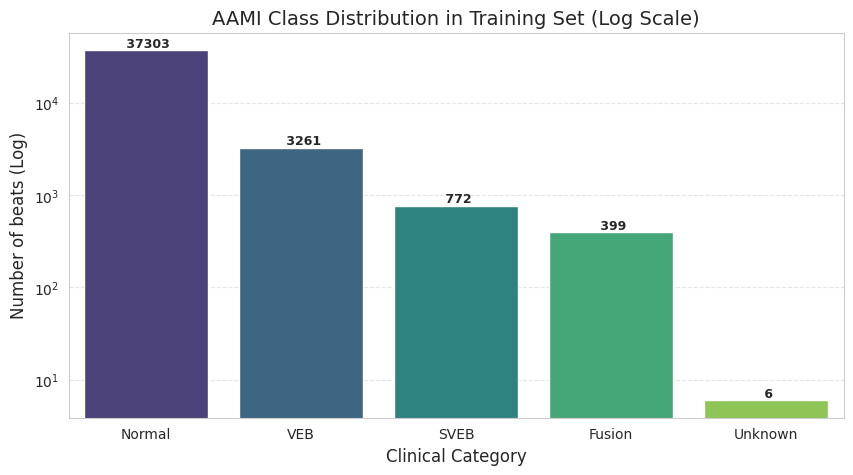

Summary statistics:
 - Normal  :  37303 beats (89.37%)
 - VEB     :   3261 beats ( 7.81%)
 - SVEB    :    772 beats ( 1.85%)
 - Fusion  :    399 beats ( 0.96%)
 - Unknown :      6 beats ( 0.01%)


In [27]:
# Collect all AAMI labels from training records for EDA
all_syms = []
for r in TRAIN_RECORDS:
    ann = wfdb.rdann(os.path.join(DATA_DIR, r), 'atr')
    all_syms.extend(ann.symbol)

# Filter out 'Other' to focus on AAMI classes
aami_labels = [get_aami_category(s) for s in all_syms if get_aami_category(s) != 'Other']
counts = Counter(aami_labels)

# Prepare data for Seaborn
categories = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")


ax = sns.barplot(x=categories, y=values, hue=categories, palette='viridis', legend=False)
plt.yscale('log')
plt.title('AAMI Class Distribution in Training Set (Log Scale)', fontsize=14)
plt.ylabel('Number of beats (Log)', fontsize=12)
plt.xlabel('Clinical Category', fontsize=12)

# Add absolute counts on top of bars for clarity
for i, v in enumerate(values):
    ax.text(i, v, f' {v}', ha='center', va='bottom', fontsize=9, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Summary statistics:")
for cls, count in counts.items():
    perc = (count / len(aami_labels)) * 100
    print(f" - {cls:8}: {count:6} beats ({perc:5.2f}%)")

### 1.6 Quick Record Analysis

Let's visualize 10 seconds of raw signal from record 100. Annotations indicate the beat type according to the AAMI standard (e.g., 'N' for Normal, 'V' for VEB).

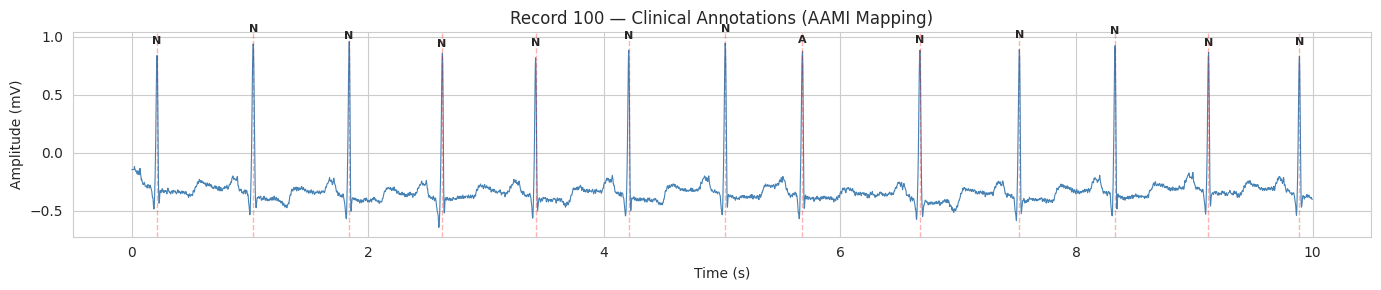

In [28]:
record     = wfdb.rdrecord(os.path.join(DATA_DIR, '100'))
annotation = wfdb.rdann(os.path.join(DATA_DIR, '100'), 'atr')

signal      = record.p_signal[:, 0]
ann_samples = annotation.sample
ann_symbols = np.array(annotation.symbol)

n_samples = 10 * FS
t         = np.arange(n_samples) / FS
mask      = ann_samples < n_samples

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, signal[:n_samples], color='steelblue', lw=0.8, label='ECG signal')

for s, sym in zip(ann_samples[mask], ann_symbols[mask]):
    cat = get_aami_category(sym)
    if cat != 'Other':
        ax.axvline(s / FS, color='red', alpha=0.3, lw=1, linestyle='--')
        ax.text(s / FS, signal[s] + 0.1, sym, fontsize=8, weight='bold', ha='center')

ax.set(xlabel='Time (s)', ylabel='Amplitude (mV)',
       title='Record 100 — Clinical Annotations (AAMI Mapping)')
plt.tight_layout()
plt.show()

### 2.1 Beat Extraction and Processing

We define a function `load_records_filtered` that iterates through the MIT-BIH records and performs the following for each:

1. **Frequency Filtering**: Applies a Butterworth band-pass filter (0.5 – 45 Hz) to the entire signal to remove baseline wander and high-frequency noise.
2. **Peak-Centered Windowing**: For every annotated beat, it crops a segment of 180 samples (approx. 500ms) centered on the R-peak.
3. **Z-score Normalization**: Subtracts the mean and divides by the standard deviation of the individual segment to remove scale variations.
4. **Label Filtering**: Only keeps beats belonging to the 5 valid AAMI classes (Normal, SVEB, VEB, Fusion, Paced).

In [29]:
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def load_records_filtered_and_rr(record_list, is_train=False):
    x_data = []
    rr_data = []  # Nuova lista per le feature numeriche (Intervalli RR)
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3, 'Paced': 4}

    # Moltiplicatori per la Data Augmentation
    augmentation_map = {0: 0, 1: 5, 2: 2, 3: 15, 4: 0}

    # Pool di shift validi: creiamo l'array saltando matematicamente lo 0
    valid_shifts = np.concatenate((np.arange(-12, 0), np.arange(1, 13)))

    for record_id in record_list:
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])

            if category in label_map:
                label_idx = label_map[category]

                # --- 1. CALCOLO INTERVALLI RR ---
                # Distanza in campioni dal picco precedente (se è il primo, usiamo il successivo come stima)
                rr_pre = peaks[i] - peaks[i-1] if i > 0 else peaks[i+1] - peaks[i]
                # Distanza in campioni dal picco successivo (se è l'ultimo, usiamo il precedente)
                rr_post = peaks[i+1] - peaks[i] if i < len(peaks)-1 else peaks[i] - peaks[i-1]

                # Convertiamo in secondi per dare alla rete una metrica universale
                rr_features = [rr_pre / FS, rr_post / FS]
                # --------------------------------

                segments_to_extract = []

                # Finestra standard centrata
                start_std = peaks[i] - HALF_WINDOW
                end_std = peaks[i] + HALF_WINDOW
                if start_std > 0 and end_std < len(signal):
                    segments_to_extract.append((start_std, end_std))

                # --- 2. DATA AUGMENTATION (JITTERING) ---
                if is_train and label_idx in augmentation_map:
                    num_shifts = augmentation_map[label_idx]
                    if num_shifts > 0:
                        # Peschiamo dal pool che non contiene lo 0
                        shifts = np.random.choice(valid_shifts, num_shifts, replace=False)
                        for shift in shifts:
                            start_shift = (peaks[i] + shift) - HALF_WINDOW
                            end_shift = (peaks[i] + shift) + HALF_WINDOW
                            if start_shift > 0 and end_shift < len(signal):
                                segments_to_extract.append((start_shift, end_shift))

                # --- 3. ESTRAZIONE E SALVATAGGIO ---
                for start, end in segments_to_extract:
                    segment = signal[start:end]
                    # Z-score Normalization
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                    x_data.append(segment)         # Array 1D morfologico
                    rr_data.append(rr_features)    # Array numerico [rr_pre, rr_post]
                    y_data.append(label_idx)       # Label clinica

    return np.array(x_data), np.array(rr_data), np.array(y_data)

print("Funzione di estrazione con Jittering e Intervalli RR definita con successo.")

Funzione di estrazione con Jittering e Intervalli RR definita con successo.


### 2.2 Dataset Creation

Now, we apply the processing function to our split records (Train, Validation, and Test). This step may take a few moments as it processes thousands of heartbeats.

In [30]:
print("Estrazione Training Set (Filtrato + Augmentation + RR)...")
# Nota il parametro is_train=True
X_train, X_train_rr, y_train_raw = load_records_filtered_and_rr(TRAIN_RECORDS, is_train=True)

print("Estrazione Validation Set (Filtrato + RR | NO Augmentation)...")
X_val, X_val_rr, y_val_raw = load_records_filtered_and_rr(VAL_RECORDS, is_train=False)

print("Estrazione Test Set (Filtrato + RR | NO Augmentation)...")
X_test, X_test_rr, y_test_raw = load_records_filtered_and_rr(TEST_RECORDS, is_train=False)

inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)', 4: 'Paced (P)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"\n{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")
# Stampa di verifica
print_clean_dist(y_train_raw, "Train (Dopo Augmentation)")
# Mapping for readable output

print_clean_dist(y_train_raw, "Train")
print_clean_dist(y_val_raw, "Validation")
print_clean_dist(y_test_raw, "Test")

# Keep as numpy arrays for the models
y_train, y_val, y_test = y_train_raw, y_val_raw, y_test_raw

Estrazione Training Set (Filtrato + Augmentation + RR)...
Estrazione Validation Set (Filtrato + RR | NO Augmentation)...
Estrazione Test Set (Filtrato + RR | NO Augmentation)...

Train (Dopo Augmentation) Distribution:
 - Normal (N): 37296
 - SVEB (S): 4632
 - VEB (V): 9783
 - Fusion (F): 6368

Train Distribution:
 - Normal (N): 37296
 - SVEB (S): 4632
 - VEB (V): 9783
 - Fusion (F): 6368

Validation Distribution:
 - Normal (N): 8560
 - SVEB (S): 172
 - VEB (V): 527
 - Fusion (F): 16

Test Distribution:
 - Normal (N): 44246
 - SVEB (S): 1837
 - VEB (V): 3220
 - Fusion (F): 388
